### Gpu Setup

In [1]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


### Prepare a Small Coupus

In [2]:
sentences = [
"king is a royal man",
"queen is a royal woman",
"king rules the kingdom",
"queen rules the kingdom",
"king lives in the palace",
"queen lives in the palace",
"prince is a young man",
"princess is a young woman",
"prince lives in the palace",
"princess lives in the palace",
"man is a male person",
"woman is a female person",
"boy is a young male",
"girl is a young female",
"dog is an animal",
"cat is an animal",
"dog is a pet",
"cat is a pet",
"puppy is a young dog",
"kitten is a young cat",
"apple is a fruit",
"banana is a fruit",
"orange is a fruit",
"apple is sweet",
"banana is sweet",
"orange is sweet",
"car is a vehicle",
"bus is a vehicle",
"truck is a vehicle",
"car moves on road",
"bus moves on road",
"truck moves on road",
]

### Tokenize
sentences의 문장들을 token 단위로 분해하여 각각 리스트로 저장

In [3]:
corpus = []
for sentence in sentences:
    tokens = sentence.lower().split()
    corpus.append(tokens)

for tokens in corpus[:5]:
    print(tokens)

['king', 'is', 'a', 'royal', 'man']
['queen', 'is', 'a', 'royal', 'woman']
['king', 'rules', 'the', 'kingdom']
['queen', 'rules', 'the', 'kingdom']
['king', 'lives', 'in', 'the', 'palace']


### Build Vocabulary
Word2Vec은 문자열을 인식하지 못하기 때문에 문자열을 정수형 id로 변환

In [4]:
words = []
for sentence in corpus:
    words.extend(sentence) # .extend(): 각각의 리스트의 내용들을 하나의 리스트로 만든다.

vocab = sorted(set(words)) # 중복 제거 후 정렬
word_to_id = {
    word:i # key, value로 매핑
    for i, word in enumerate(vocab)
}

id_to_word = {
    i:word
    for word, i in word_to_id.items()
}

vocab_size = len(vocab)
print("Vocabulary size", vocab_size)
print(word_to_id)
print(id_to_word)

Vocabulary size 40
{'a': 0, 'an': 1, 'animal': 2, 'apple': 3, 'banana': 4, 'boy': 5, 'bus': 6, 'car': 7, 'cat': 8, 'dog': 9, 'female': 10, 'fruit': 11, 'girl': 12, 'in': 13, 'is': 14, 'king': 15, 'kingdom': 16, 'kitten': 17, 'lives': 18, 'male': 19, 'man': 20, 'moves': 21, 'on': 22, 'orange': 23, 'palace': 24, 'person': 25, 'pet': 26, 'prince': 27, 'princess': 28, 'puppy': 29, 'queen': 30, 'road': 31, 'royal': 32, 'rules': 33, 'sweet': 34, 'the': 35, 'truck': 36, 'vehicle': 37, 'woman': 38, 'young': 39}
{0: 'a', 1: 'an', 2: 'animal', 3: 'apple', 4: 'banana', 5: 'boy', 6: 'bus', 7: 'car', 8: 'cat', 9: 'dog', 10: 'female', 11: 'fruit', 12: 'girl', 13: 'in', 14: 'is', 15: 'king', 16: 'kingdom', 17: 'kitten', 18: 'lives', 19: 'male', 20: 'man', 21: 'moves', 22: 'on', 23: 'orange', 24: 'palace', 25: 'person', 26: 'pet', 27: 'prince', 28: 'princess', 29: 'puppy', 30: 'queen', 31: 'road', 32: 'royal', 33: 'rules', 34: 'sweet', 35: 'the', 36: 'truck', 37: 'vehicle', 38: 'woman', 39: 'young'}


### Generate Skip-gram Training Pair

중심 단어와 주변 단어의 쌍을 생성하는 함수
(참고) start = max(0, i - window)
예를 들어 [a, b, c, d, e] 이렇게 구성되어 있고, center = b, window = 2일 경우 window의 맨 왼쪽 값은 계산에서 제외 한다는 것

In [ ]:
def create_skipgram_pairs(corpus, window = 2):
    pairs = []

    for sentence in corpus:
        for i in range(len(sentence)):
            center_word = sentence[i]
            start = max(0, i - window) # center보다 왼쪽에 있는 단어가 왼쪽으로 벗어나있을 경우
            end = min(len(sentence), i + window + 1)
            for j in range(start, end):
                if i == j:
                    continue
                context_word = sentence[j]
                center_id = word_to_id[center_word]
                context_id = word_to_id[context_word]
                pairs.append((center_id, context_id))
    return pairs

[(15, 14), (15, 0), (14, 15), (14, 0), (14, 32), (0, 15), (0, 14), (0, 32), (0, 20), (32, 14), (32, 0), (32, 20), (20, 0), (20, 32), (30, 14), (30, 0), (14, 30), (14, 0), (14, 32), (0, 30), (0, 14), (0, 32), (0, 38), (32, 14), (32, 0), (32, 38), (38, 0), (38, 32), (15, 33), (15, 35), (33, 15), (33, 35), (33, 16), (35, 15), (35, 33), (35, 16), (16, 33), (16, 35), (30, 33), (30, 35), (33, 30), (33, 35), (33, 16), (35, 30), (35, 33), (35, 16), (16, 33), (16, 35), (15, 18), (15, 13), (18, 15), (18, 13), (18, 35), (13, 15), (13, 18), (13, 35), (13, 24), (35, 18), (35, 13), (35, 24), (24, 13), (24, 35), (30, 18), (30, 13), (18, 30), (18, 13), (18, 35), (13, 30), (13, 18), (13, 35), (13, 24), (35, 18), (35, 13), (35, 24), (24, 13), (24, 35), (27, 14), (27, 0), (14, 27), (14, 0), (14, 39), (0, 27), (0, 14), (0, 39), (0, 20), (39, 14), (39, 0), (39, 20), (20, 0), (20, 39), (28, 14), (28, 0), (14, 28), (14, 0), (14, 39), (0, 28), (0, 14), (0, 39), (0, 38), (39, 14), (39, 0), (39, 38), (38, 0), (

### Generate Skip-gram Training Pair

훈련 데이터셋을 출력

In [6]:
pairs = create_skipgram_pairs(corpus, window = 2)
print("No of training pairs:", len(pairs))
for center_id, context_id in pairs[:20]:
    print(id_to_word[center_id], "->", id_to_word[context_id])

No of training pairs: 364
king -> is
king -> a
is -> king
is -> a
is -> royal
a -> king
a -> is
a -> royal
a -> man
royal -> is
royal -> a
royal -> man
man -> a
man -> royal
queen -> is
queen -> a
is -> queen
is -> a
is -> royal
a -> queen


### Convert Training Data to Tensors

위에서 생성한 훈련 데이터를 pytorch에서 바로 사용할 수 있도록 tensor 형태로 가공

In [7]:
center_words = torch.tensor([pair[0] for pair in pairs], dtype = torch.long)
context_words = torch.tensor([pair[1] for pair in pairs], dtype = torch.long)

print(center_words.shape)
print(context_words.shape)

torch.Size([364])
torch.Size([364])


### Use DataLoader

In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

dataset = TensorDataset(center_words, context_words) # center word와 context word를 하나로 묶음

# DataLoader를 사용해서 데이터 셋에서 데이터들을 64개씩 랜덤하게 가져온다.
loader = DataLoader(dataset, batch_size = 64, shuffle = True)

### Build the Skip-gram Neural Network

In [13]:
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim): #
        # skip gram 모델의 레이어들을 초기화하는 생성자 함수
        # vocab_size = 전체 단어 집합의 크기
        # embedding_dim: 각 단어를 표현할 임베딩 벡터의 차원 수
        super().__init__()
        # 단어 아이디를 입력 받아 densevector로 변환해준다.
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 임베딩된 벡터를 다시 전체 단어장 크기의 점수로 변환해 주는 선형 레이어
        self.output = nn.Linear(embedding_dim, vocab_size)

    # 모델에 데이터를 입력해 forward propagation을 수행하는 함수
    def forward(self, center_words):
        embedded = self.embedding(center_words)
        logits = self.output(embedded)
        return logits
    

### [torch.nn]
pytorch에서 신경망을 구성하기 위한 클래스들을 모아놓은 패키지

직접 가중치 행렬을 만들고 backpropagation 코드를 전부 작성하지 않아도 torch.nn이 학습 가능한 파라미터를 가진 층을 쉽게 만들 수 있게 해준다.

### [torch.nn.Embedding]
학습 가능한 lookup table
이론에서의 Embedding Matrix를 만들어준다.

### [torch.nn.Linear]
Linear Tranformation을 수행해준다.

### Build the Skip-gram Neural Network
위에서 정의한 SkipGramModel 클래스를 실제 메모리에 생성하고 GPU로 배치한 뒤 모델의 구조를 출력

In [14]:
embedding_dim = 50

model = SkipGramModel(vocab_size, embedding_dim)
model = model.to(device)
print(model)

SkipGramModel(
  (embedding): Embedding(40, 50)
  (output): Linear(in_features=50, out_features=40, bias=True)
)


### Loss & Optimizer

In [ ]:
# 모델이 예측한 결과와 실제 정답의 오차를 계산
criterion = nn.CrossEntropyLoss()
# 계산된 오차를 바탕으로 파라미터를 어떻게 수정할지 결정하고 업데이트
# adam을 사용, 학습률 = 0.01.(학습률이 너무 크면 학습이 널뛰기 한다.)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

### Train Word2Vec on GPU

In [ ]:
epochs = 200 # 학습 반복 횟수

for epoch in range(epochs):
    total_loss = 0
    for centers, contexts in loader:
        centers = centers.to(device)
        contexts = contexts.to(device)
        #pytorch는 backpropagation을 할 때 이전 gradient를 누적하기 때문에 매 학습마다 0으로 비워준다.
        optimizer.zero_grad()

        logits = model(centers) # center word들을 model에 넣어서 전체 단어장에 대한 logit(예측 점수)를 구한다.
        loss = criterion(logits, contexts) # 예측 점수와 실제 주변 단어를 비교하여 loss를 계산
        loss.backward() # backpropagation을 수행 -> gradient를 계산
        optimizer.step() # 계산된 gradient를 바탕으로 model의 parameter를 업데이트
        total_loss += loss.item() # 이번 batch에서 발생할 loss 값을 더해둡니다.(평균 loss 계산용)

    # 평균 loss를 계산하여 출력
    if (epoch + 1) % 20 == 0:
        average_loss = (total_loss / len(loader))
        print(f"Epoch {epoch + 1:3d}, " f"Loss: {average_loss:.4f}")

Epoch  20, Loss: 1.9177
Epoch  40, Loss: 1.9121
Epoch  60, Loss: 1.9060
Epoch  80, Loss: 1.9249
Epoch 100, Loss: 1.9214
Epoch 120, Loss: 1.9094
Epoch 140, Loss: 1.9159
Epoch 160, Loss: 1.8980
Epoch 180, Loss: 1.8995
Epoch 200, Loss: 1.9098


### Extract Learned Embeddings
"king"의 embedding vector를 출력

In [ ]:
embeddings = model.embedding.weight
print(embeddings.shape)
print(embeddings.device)

king_id = word_to_id["king"]
king_vector = embeddings[king_id]
print(king_vector)

torch.Size([40, 50])
cuda:0
tensor([ 0.7316,  2.7009,  0.5548,  0.1591, -0.8048,  0.7932, -0.7973, -0.3172,
        -0.6350,  0.9266,  0.0626,  0.7120, -0.1123, -0.3555,  0.3478,  1.0457,
        -2.4390, -2.5427,  0.6285, -0.3121, -0.6099, -0.0860,  2.2710, -0.0183,
         0.1284,  0.1748, -0.2160,  0.1171, -0.5765, -0.0558, -1.1020,  0.5870,
        -0.3538,  0.1073,  0.6629,  2.1151, -0.7837,  0.9434,  1.4763, -1.0186,
        -1.0725, -0.4236,  1.5835, -1.8819,  0.1275,  0.2823,  1.8713, -1.2476,
        -0.8127, -2.3319], device='cuda:0', grad_fn=<SelectBackward0>)


### Cosine Similarity
학습이 끝난 Word2Vec 모델의 단어 벡터를 바탕으로, 두 단어가 서로 얼마나 의미가 비슷한지(유사도)를 계산해 주는 함수

In [21]:
import torch.nn.functional as F

def similarity(word1, word2):
    id1 = word_to_id[word1]
    id2 = word_to_id[word2]
    v1 = embeddings[id1]
    v2 = embeddings[id2]

    score = F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0))

    return score.item()


print("king - queen", similarity("king", "queen"))
print("dog - cat", similarity("dog", "cat"))
print("apple - banana", similarity("apple", "banana"))
print("dog - car", similarity("dog", "car"))

king - queen 0.16928981244564056
dog - cat 0.26904749870300293
apple - banana 0.5212311744689941
dog - car 0.17792481184005737


### Nearest Neighbor Search

In [25]:
# 모델이 학습한 전체 단어 embedding vector의 크기를 정규화하여 unit vector로 만든다.
normalized_embeddings = F.normalize(embeddings, p = 2, dim = 1)

def most_similar(word, top_k = 5):
    word_id = word_to_id[word]
    target = normalized_embeddings[word_id]
    similarities = torch.matmul(normalized_embeddings, target)
    values, indices = torch.topk(similarities, k = top_k + 1)
    results = []
    for score, idx in zip(values.tolist(), indices.tolist()):
        candidate = id_to_word[idx]
        if candidate != word:
            results.append((candidate, score))
        if len(results) == top_k:
            break

    return results

print(most_similar("king", top_k = 3))

[('palace', 0.39769089221954346), ('pet', 0.3430473208427429), ('truck', 0.32786738872528076)]


### Similarity Visualization

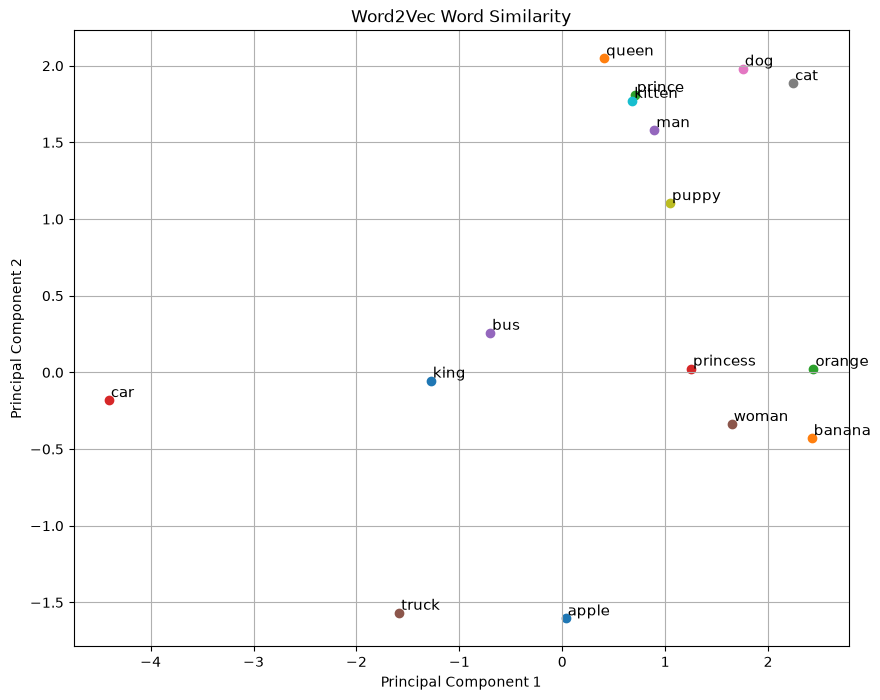

In [26]:
embedding_cpu = (model.embedding.weight.detach().cpu().numpy())

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embedding_cpu)

words = [
"king", "queen",
"prince", "princess",
"man", "woman",
"dog", "cat",
"puppy", "kitten",
"apple", "banana", "orange",
"car", "bus", "truck"
]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

for i, word in enumerate(words):
    x = vectors_2d[i, 0]
    y = vectors_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=11)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Word2Vec Word Similarity")
plt.grid(True)
plt.show()